#1. **ID3** использует **информационный выигрыш (Information Gain)**

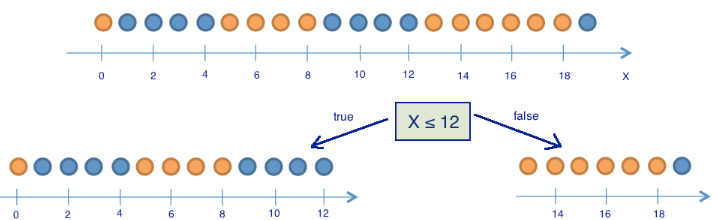

https://habr.com/ru/companies/ods/articles/322534/

In [204]:
import numpy as np
a = [int(i) for i in '01111000011110000001']
l0, l1 = [], a[:]
c0, c1, c_ = a.count(0), a.count(1), len(a)
print(f'{c0 = }, {c1 = }, {c_ = }')
p0, p1 = c0/c_, c1/c_
s0 = -p0*np.log2(p0)-p1*np.log2(p1)
print(f'{p0 = }, {p1 = }, {s0 = :.3f}')
print()
for i in range(len(a)-1):
  l0.append(l1.pop(0))
  c0l0, c1l0, c0l1, c1l1 = l0.count(0), l0.count(1), l1.count(0), l1.count(1)
  p0l0, p1l0, p0l1, p1l1 = max(c0l0/len(l0), 0.00001), max(c1l0/len(l0), 0.00001), max(c0l1/len(l1), 0.00001), max(c1l1/len(l1), 0.00001)
  s1 = -p0l0*np.log2(p0l0)-p1l0*np.log2(p1l0)
  s2 = -p0l1*np.log2(p0l1)-p1l1*np.log2(p1l1)
  ig = s0 - (len(l0)/c_*s1 + len(l1)/c_*s2)
  print(''.join(map(str, l0)))
  print(f"s1 = {s1:.3f}, s2 = {s2:.3f}, ig = {ig:.3f}")

c0 = 11, c1 = 9, c_ = 20
p0 = 0.55, p1 = 0.45, s0 = 0.993

0
s1 = 0.000, s2 = 0.998, ig = 0.045
01
s1 = 1.000, s2 = 0.991, ig = 0.001
011
s1 = 0.918, s2 = 0.977, ig = 0.024
0111
s1 = 0.811, s2 = 0.954, ig = 0.067
01111
s1 = 0.722, s2 = 0.918, ig = 0.124
011110
s1 = 0.918, s2 = 0.940, ig = 0.059
0111100
s1 = 0.985, s2 = 0.961, ig = 0.023
01111000
s1 = 1.000, s2 = 0.980, ig = 0.005
011110000
s1 = 0.991, s2 = 0.994, ig = 0.000
0111100001
s1 = 1.000, s2 = 0.971, ig = 0.007
01111000011
s1 = 0.994, s2 = 0.918, ig = 0.033
011110000111
s1 = 0.980, s2 = 0.811, ig = 0.080
0111100001111
s1 = 0.961, s2 = 0.592, ig = 0.161
01111000011110
s1 = 0.985, s2 = 0.650, ig = 0.108
011110000111100
s1 = 0.997, s2 = 0.722, ig = 0.065
0111100001111000
s1 = 1.000, s2 = 0.811, ig = 0.031
01111000011110000
s1 = 0.998, s2 = 0.918, ig = 0.007
011110000111100000
s1 = 0.991, s2 = 1.000, ig = 0.001
0111100001111000000
s1 = 0.982, s2 = 0.000, ig = 0.060



```
c0 = 11, c1 = 9, c_ = 20
p0 = 0.55, p1 = 0.45, s0 = 0.993

0
s1 = -0.000, s2 = 0.998, ig = 0.045
01
s1 = 1.000, s2 = 0.991, ig = 0.001
011
s1 = 0.918, s2 = 0.977, ig = 0.024
0111
s1 = 0.811, s2 = 0.954, ig = 0.067
01111
s1 = 0.722, s2 = 0.918, ig = 0.124
011110
s1 = 0.918, s2 = 0.940, ig = 0.059
0111100
s1 = 0.985, s2 = 0.961, ig = 0.023
01111000
s1 = 1.000, s2 = 0.980, ig = 0.005
011110000
s1 = 0.991, s2 = 0.994, ig = 0.000
0111100001
s1 = 1.000, s2 = 0.971, ig = 0.007
01111000011
s1 = 0.994, s2 = 0.918, ig = 0.033
011110000111
s1 = 0.980, s2 = 0.811, ig = 0.080
0111100001111
s1 = 0.961, s2 = 0.592, ig = 0.161
01111000011110
s1 = 0.985, s2 = 0.650, ig = 0.108
011110000111100
s1 = 0.997, s2 = 0.722, ig = 0.065
0111100001111000
s1 = 1.000, s2 = 0.811, ig = 0.031
01111000011110000
s1 = 0.998, s2 = 0.918, ig = 0.007
011110000111100000
s1 = 0.991, s2 = 1.000, ig = 0.001
0111100001111000000
s1 = 0.982, s2 = -0.000, ig = 0.060
```



### **Пояснения к коду:**
1. **`a`**:
   - Это список чисел, который вы анализируете `[0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1]`.

2. **`l0` и `l1`**:
   - `l0` — это список, в который постепенно добавляются элементы из `a` (начиная с первого элемента).
   - `l1` — это оставшаяся часть списка `a` после удаления элементов, добавленных в `l0`.

3. **`c0`**:
   - Количество нулей (`0`) в текущем списке (либо в `a`, либо в `l0` или `l1`).

4. **`c1`**:
   - Количество единиц (`1`) в текущем списке (либо в `a`, либо в `l0` или `l1`).

5. **`c_`**:
   - Общее количество элементов в текущем списке (либо в `a`, либо в `l0` или `l1`).

6. **`p0`**:
   - Вероятность появления нуля (`0`) в текущем списке. Вычисляется как `c0 / c_`.

7. **`p1`**:
   - Вероятность появления единицы (`1`) в текущем списке. Вычисляется как `c1 / c_`.

8. **`s0`**:
   - Энтропия исходного списка `a`. Это мера неопределенности исходного распределения. Вычисляется по формуле:

$$s0 = -p0 \cdot \log_2(p0) - p1 \cdot \log_2(p1)$$

9. **`s1`**:
   - Энтропия списка `l0`. Вычисляется аналогично `s0`, но для списка `l0`.

10. **`s2`**:
    - Энтропия списка `l1`. Вычисляется аналогично `s0`, но для списка `l1`.

11. **`ig`**:
    - **Information Gain (Информационный выигрыш)**. Это мера того, насколько уменьшается неопределенность (энтропия) после разделения списка `a` на `l0` и `l1`. Вычисляется по формуле:
      $$
      ig = s0 - \left( \frac{|l0|}{|a|} \cdot s1 + \frac{|l1|}{|a|} \cdot s2 \right)
      $$
      где $|l0|$ и $|l1|$ — длины списков `l0` и `l1`, а $|a|$ — длина исходного списка.

---

#2. **C4.5** использует **коэффициент усиления (Gain Ratio)**, который нормализует информационный выигрыш, чтобы избежать предпочтения признаков с большим количеством значений

In [205]:
import numpy as np
a = [int(i) for i in '01111000011110000001']
l0, l1 = [], a[:]

t = a[0]
l = [t]
for i in range(1, len(a)):
  l0.append(l1.pop(0))
  if a[i]!=t:
    t = a[i]
    print(''.join(map(str, l0)))
    c0l0, c1l0, c0l1, c1l1 = l0.count(0), l0.count(1), l1.count(0), l1.count(1)
    p0l0, p1l0, p0l1, p1l1 = max(c0l0/len(l0), 0.00001), max(c1l0/len(l0), 0.00001), max(c0l1/len(l1), 0.00001), max(c1l1/len(l1), 0.00001)
    s1 = -p0l0*np.log2(p0l0)-p1l0*np.log2(p1l0)
    s2 = -p0l1*np.log2(p0l1)-p1l1*np.log2(p1l1)
    ig = s0 - (len(l0)/len(a)*s1 + len(l1)/len(a)*s2)
    iv = -(len(l0)/len(a)*np.log2(len(l0)/len(a)) + len(l1)/len(a)*np.log2(len(l1)/len(a)))
    try:
      gr = ig/iv
    except:
      gr = 0

    print(f"s1 = {s1:.3f}, s2 = {s2:.3f}, ig = {ig:.3f}, iv = {iv:.3f}, gr = {gr:.3f}")
    

0
s1 = 0.000, s2 = 0.998, ig = 0.045, iv = 0.286, gr = 0.156
01111
s1 = 0.722, s2 = 0.918, ig = 0.124, iv = 0.811, gr = 0.152
011110000
s1 = 0.991, s2 = 0.994, ig = 0.000, iv = 0.993, gr = 0.000
0111100001111
s1 = 0.961, s2 = 0.592, ig = 0.161, iv = 0.934, gr = 0.172
0111100001111000000
s1 = 0.982, s2 = 0.000, ig = 0.060, iv = 0.286, gr = 0.209



```
c0 = 11, c1 = 9, c_ = 20
p0 = 0.55, p1 = 0.45, s0 = 0.993

0
s1 = -0.000, s2 = 0.998, ig = 0.045, iv = 0.286, gr = 0.156
01111
s1 = 0.722, s2 = 0.918, ig = 0.124, iv = 0.811, gr = 0.152
011110000
s1 = 0.991, s2 = 0.994, ig = 0.000, iv = 0.993, gr = 0.000
0111100001111
s1 = 0.961, s2 = 0.592, ig = 0.161, iv = 0.934, gr = 0.172
0111100001111000000
s1 = 0.982, s2 = -0.000, ig = 0.060, iv = 0.286, gr = 0.209
```



### **Код (с Gain Ratio):**
1. **`iv`**:
   - **Intrinsic Information (Внутренняя информация)**. Это мера того, насколько сложно разделить список на `l0` и `l1`. Вычисляется по формуле:
$$iv = -\left( \frac{|l0|}{|a|} \cdot \log_2\left(\frac{|l0|}{|a|}\right) + \frac{|l1|}{|a|} \cdot \log_2\left(\frac{|l1|}{|a|}\right) \right)$$
     Она используется для нормализации Information Gain.

2. **`gr`**:
   - **Gain Ratio (Коэффициент усиления)**. Это нормализованная версия Information Gain, которая учитывает сложность разделения. Вычисляется по формуле:
     $$
     gr = \frac{ig}{iv}
     $$
     Если `iv = 0`, то `gr = 0` (чтобы избежать деления на ноль).

---

### **Пример вычислений:**
Для списка `a = [0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1]`:

1. **Исходные значения**:
   - `c0 = 11` (количество нулей),
   - `c1 = 9` (количество единиц),
   - `c_ = 20` (общее количество элементов),
   - `p0 = 0.55` (вероятность нуля),
   - `p1 = 0.45` (вероятность единицы),
   - `s0 = 0.993` (энтропия исходного списка).

2. **После первого шага**:
   - `l0 = [0]`, `l1 = [1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1]`,
   - Для `l0`:
     - `c0 = 1`, `c1 = 0`, `c_ = 1`,
     - `p0 = 1.0`, `p1 = 0.0`,
     - `s1 = 0.0` (энтропия `l0`).
   - Для `l1`:
     - `c0 = 10`, `c1 = 9`, `c_ = 19`,
     - `p0 = 10/19`, `p1 = 9/19`,
     - `s2 = 0.998` (энтропия `l1`).
   - `ig = 0.993 - (0.0 * 1/20 + 0.998 * 19/20) = 0.045`.

3. **Gain Ratio**:
   - `iv = - (1/20 * log2(1/20) + 19/20 * log2(19/20)) = 0.286`,
   - `gr = 0.045 / 0.286 = 0.156`.

---

### **Основные моменты:**
- **`c0`, `c1`, `c_`** — это счетчики и общее количество элементов.
- **`p0`, `p1`** — вероятности появления нулей и единиц.
- **`s0`, `s1`, `s2`** — энтропии исходного списка и его частей.
- **`ig`** — Information Gain, мера уменьшения неопределенности.
- **`iv`** — Intrinsic Information, сложность разделения.
- **`gr`** — Gain Ratio, нормализованный Information Gain.

---

#3. **CART**: Использует **Gini Index** для классификации и **Mean Squared Error** (MSE) для регрессии.

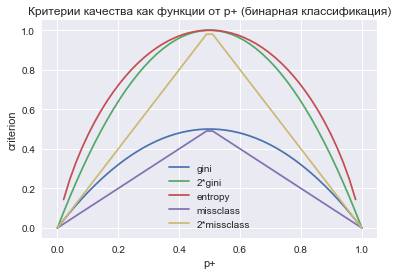


1. **Критерий разделения**:
   - Вместо энтропии и Gain Ratio используется **Gini Index**.
   - Gini Index вычисляется как:
   $$
   \text{Gini} = 1 - \sum_{i=1}^k p_i^2
   $$
  где $ p_i $ — вероятность класса $ i $.

2. **Взвешенный Gini Index**:
   - Для оценки качества разделения используется взвешенный Gini Index:
    $$
    \text{Weighted Gini} = \frac{|l0|}{|a|} \cdot \text{Gini}(l0) + \frac{|l1|}{|a|} \cdot \text{Gini}(l1)
     $$


In [206]:
import numpy as np
a = [int(i) for i in '01111000011110000001']
l0, l1 = [], a[:]

c0, c1, c_ = a.count(0), a.count(1), len(a)
print(f'{c0 = }, {c1 = }, {c_ = }')
p0, p1 = c0/c_, c1/c_
gini = 1-(p0**2+p1**2)
print(f'{p0 = }, {p1 = }, {gini = :.3f}')
print()

t = a[0]
l = [t]
for i in range(1, len(a)):
  l0.append(l1.pop(0))
  if a[i]!=t:
    t = a[i]
    print(''.join(map(str, l0)))
    c0l0, c1l0, c0l1, c1l1 = l0.count(0), l0.count(1), l1.count(0), l1.count(1)
    p0l0, p1l0, p0l1, p1l1 = max(c0l0/len(l0), 0.00001), max(c1l0/len(l0), 0.00001), max(c0l1/len(l1), 0.00001), max(c1l1/len(l1), 0.00001)
    g1 = 1-(p0l0**2+p1l0**2)
    g2 = 1-(p0l1**2+p1l1**2)
    wg = len(l0)/len(a)*g1 + len(l1)/len(a)*g2
    print(f"g1 = {g1:.3f}, g2 = {g2:.3f}, wg = {wg:.3f}")

c0 = 11, c1 = 9, c_ = 20
p0 = 0.55, p1 = 0.45, gini = 0.495

0
g1 = -0.000, g2 = 0.499, wg = 0.474
01111
g1 = 0.320, g2 = 0.444, wg = 0.413
011110000
g1 = 0.494, g2 = 0.496, wg = 0.495
0111100001111
g1 = 0.473, g2 = 0.245, wg = 0.393
0111100001111000000
g1 = 0.488, g2 = -0.000, wg = 0.463



```
c0 = 11, c1 = 9, c_ = 20
p0 = 0.55, p1 = 0.45, gini = 0.495

0
g1 = 0.000, g2 = 0.499, wg = 0.474
01111
g1 = 0.320, g2 = 0.444, wg = 0.413
011110000
g1 = 0.494, g2 = 0.496, wg = 0.495
0111100001111
g1 = 0.473, g2 = 0.245, wg = 0.393
0111100001111000000
g1 = 0.488, g2 = 0.000, wg = 0.463
```



#4. Найдите первый узел дерева, перебрав все параметры. Какой получится accuracy после первого разбиения?

In [207]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris

iris = load_iris()
df = pd.DataFrame(iris.data, columns=list('1234'))
df['y'] = (iris.target != 0)*1
df

,1,2,3,4,y
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,1
146,6.3,2.5,5.0,1.9,1
147,6.5,3.0,5.2,2.0,1
148,6.2,3.4,5.4,2.3,1


In [208]:
df1 = df.sort_values(by=['1'])
a = df1['y'].tolist()
b = df1['1'].tolist()
np.array(a), np.array(b)

(array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]),
 array([4.3, 4.4, 4.4, 4.4, 4.5, 4.6, 4.6, 4.6, 4.6, 4.7, 4.7, 4.8, 4.8,
        4.8, 4.8, 4.8, 4.9, 4.9, 4.9, 4.9, 4.9, 4.9, 5. , 5. , 5. , 5. ,
        5. , 5. , 5. , 5. , 5. , 5. , 5.1, 5.1, 5.1, 5.1, 5.1, 5.1, 5.1,
        5.1, 5.1, 5.2, 5.2, 5.2, 5.2, 5.3, 5.4, 5.4, 5.4, 5.4, 5.4, 5.4,
        5.5, 5.5, 5.5, 5.5, 5.5, 5.5, 5.5, 5.6, 5.6, 5.6, 5.6, 5.6, 5.6,
        5.7, 5.7, 5.7, 5.7, 5.7, 5.7, 5.7, 5.7, 5.8, 5.8, 5.8, 5.8, 5.8,
        5.8, 5.8, 5.9, 5.9, 5.9, 6. , 6. , 6. , 6. , 6

In [209]:
df

,1,2,3,4,y
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,1
146,6.3,2.5,5.0,1.9,1
147,6.5,3.0,5.2,2.0,1
148,6.2,3.4,5.4,2.3,1


In [210]:
unic_col1 = sorted(list(set(b)))
np.array(unic_col1) # выбрал уникальные

array([4.3, 4.4, 4.5, 4.6, 4.7, 4.8, 4.9, 5. , 5.1, 5.2, 5.3, 5.4, 5.5,
       5.6, 5.7, 5.8, 5.9, 6. , 6.1, 6.2, 6.3, 6.4, 6.5, 6.6, 6.7, 6.8,
       6.9, 7. , 7.1, 7.2, 7.3, 7.4, 7.6, 7.7, 7.9])

In [211]:
sep_col1 = [(unic_col1[i]+unic_col1[i+1])/2 for i in range(len(unic_col1)-1)]
np.array(sep_col1) # возможные разделители выборки

array([4.35, 4.45, 4.55, 4.65, 4.75, 4.85, 4.95, 5.05, 5.15, 5.25, 5.35,
       5.45, 5.55, 5.65, 5.75, 5.85, 5.95, 6.05, 6.15, 6.25, 6.35, 6.45,
       6.55, 6.65, 6.75, 6.85, 6.95, 7.05, 7.15, 7.25, 7.35, 7.5 , 7.65,
       7.8 ])

In [212]:
np_b = np.array(b)
for i in sep_col1:
  print(np_b < i)
  break

[ True False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False]


In [213]:
bm = np_b < 4.35
bm, a

(array([ True, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
      

In [214]:
sum(bm == a)

49

In [215]:
import numpy as np
from scipy.stats import chi2_contingency
def chi_square_test(y0, y1):
    contingency_table = np.array([
        [(y0 == 0).sum(), (y0 == 1).sum()],
        [(y1 == 0).sum(), (y1 == 1).sum()]
    ])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    return chi2

np_b, np_a = np.array(b), np.array(a)
for i in sep_col1:
  left_bitmask = np_b < i
  ix = sum(left_bitmask)
  l0, l1 = np_a[left_bitmask], np_a[~left_bitmask]
  chi2 = chi_square_test(l0, l1)
  print(l0, l1, chi2, np_a)
  break

# code 4

[0] [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 1 0 0 0
 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 0 1 1 0
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1] 0.12583892617449663 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 1 0 0
 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 0 1 1
 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1]


In [216]:
a = np.array(a)
for col in range(1, 5):
    b = np.array(df[str(col)].tolist())
    unic_col = sorted(list(set(b))) 
    sep_col = np.array([(unic_col[i]+unic_col[i+1])/2 for i in range(len(unic_col)-1)])
    best_chi = 0
    best_sep = 0
    acc = 0
    for sep in sep_col:
        left_bitmask = b < sep
        l0, l1 = a[left_bitmask], a[~left_bitmask]
        chi2 = chi_square_test(l0, l1)
        if chi2 > best_chi:
            best_chi = chi2
            best_sep = sep
            acc = max(sum(a == left_bitmask), sum(a == ~left_bitmask))/len(a)
            
    print(f"column:{col}, best separator:{best_sep:.2f}, best chi2 score:{best_chi:.3f}, accuracy:{acc}")

column:1, best separator:5.45, best chi2 score:53.869, accuracy:0.8266666666666667
column:2, best separator:3.15, best chi2 score:28.214, accuracy:0.7466666666666667
column:3, best separator:2.45, best chi2 score:90.094, accuracy:0.9066666666666666
column:4, best separator:0.80, best chi2 score:90.094, accuracy:0.9066666666666666


#5. Gradient Boosting (Градиентный бустинг)

https://www.youtube.com/watch?v=G9d2likA-_E

http://arogozhnikov.github.io/2016/06/24/gradient_boosting_explained.html

http://arogozhnikov.github.io/2016/07/05/gradient_boosting_playground.html

In [217]:
import pandas as pd
import numpy as np
from sklearn.datasets import make_regression, make_classification
from sklearn.metrics import mean_absolute_error, mean_squared_error, roc_auc_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree


X, y = make_regression(n_samples=10, n_features=3, random_state=45)
df = pd.DataFrame(X)
df['y_true'] = y
df

,0,1,2,y_true
0,-2.596879,-1.271633,-0.204301,-207.864873
1,-1.750752,0.801927,-1.473314,-155.495817
2,0.394073,-0.873305,0.289681,26.305876
3,0.259596,-0.015685,0.935106,42.250301
4,0.025244,-1.008601,-0.495052,-21.757456
5,-0.499546,1.670300,-1.541367,-56.720023
6,0.332632,-0.627695,-1.393813,-17.866647
7,-0.395146,0.260322,0.026375,-25.178411
8,-0.606944,-1.546873,-0.121507,-64.217109
9,-1.654263,2.248090,0.673129,-78.462150


In [218]:
df['y_pred_0'] = df['y_true'].mean()
df

,0,1,2,y_true,y_pred_0
0,-2.596879,-1.271633,-0.204301,-207.864873,-55.900631
1,-1.750752,0.801927,-1.473314,-155.495817,-55.900631
2,0.394073,-0.873305,0.289681,26.305876,-55.900631
3,0.259596,-0.015685,0.935106,42.250301,-55.900631
4,0.025244,-1.008601,-0.495052,-21.757456,-55.900631
5,-0.499546,1.670300,-1.541367,-56.720023,-55.900631
6,0.332632,-0.627695,-1.393813,-17.866647,-55.900631
7,-0.395146,0.260322,0.026375,-25.178411,-55.900631
8,-0.606944,-1.546873,-0.121507,-64.217109,-55.900631
9,-1.654263,2.248090,0.673129,-78.462150,-55.900631


In [219]:
mean_absolute_error(df['y_true'], df['y_pred_0'])

56.651363561064976

In [220]:
# Вычисление остатков (разница между истинными значениями и предсказаниями)
df['residual_0'] = df['y_true'] - df['y_pred_0']
df

,0,1,2,y_true,y_pred_0,residual_0
0,-2.596879,-1.271633,-0.204301,-207.864873,-55.900631,-151.964242
1,-1.750752,0.801927,-1.473314,-155.495817,-55.900631,-99.595187
2,0.394073,-0.873305,0.289681,26.305876,-55.900631,82.206506
3,0.259596,-0.015685,0.935106,42.250301,-55.900631,98.150932
4,0.025244,-1.008601,-0.495052,-21.757456,-55.900631,34.143175
5,-0.499546,1.670300,-1.541367,-56.720023,-55.900631,-0.819392
6,0.332632,-0.627695,-1.393813,-17.866647,-55.900631,38.033984
7,-0.395146,0.260322,0.026375,-25.178411,-55.900631,30.722220
8,-0.606944,-1.546873,-0.121507,-64.217109,-55.900631,-8.316478
9,-1.654263,2.248090,0.673129,-78.462150,-55.900631,-22.561519


In [221]:
# Создание решающего дерева с максимальной глубиной 1 (пень)
# и обучение дерева на остатках
tree_1 = DecisionTreeRegressor(max_depth=1, random_state=3)
tree_1.fit(df[[0,1,2]], df['residual_0'])

DecisionTreeRegressor(max_depth=1, random_state=3)

In [222]:
# Предсказание дерева
df['tree_pred_1'] = tree_1.predict(df[[0,1,2]])
df

,0,1,2,y_true,y_pred_0,residual_0,tree_pred_1
0,-2.596879,-1.271633,-0.204301,-207.864873,-55.900631,-151.964242,-125.779714
1,-1.750752,0.801927,-1.473314,-155.495817,-55.900631,-99.595187,-125.779714
2,0.394073,-0.873305,0.289681,26.305876,-55.900631,82.206506,31.444929
3,0.259596,-0.015685,0.935106,42.250301,-55.900631,98.150932,31.444929
4,0.025244,-1.008601,-0.495052,-21.757456,-55.900631,34.143175,31.444929
5,-0.499546,1.670300,-1.541367,-56.720023,-55.900631,-0.819392,31.444929
6,0.332632,-0.627695,-1.393813,-17.866647,-55.900631,38.033984,31.444929
7,-0.395146,0.260322,0.026375,-25.178411,-55.900631,30.722220,31.444929
8,-0.606944,-1.546873,-0.121507,-64.217109,-55.900631,-8.316478,31.444929
9,-1.654263,2.248090,0.673129,-78.462150,-55.900631,-22.561519,31.444929


[Text(0.5, 0.75, 'x[0] <= -1.703\nsquared_error = 5353.89\nsamples = 10\nvalue = 0.0'),
 Text(0.25, 0.25, 'squared_error = 685.629\nsamples = 2\nvalue = -125.78'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'squared_error = 1577.037\nsamples = 8\nvalue = 31.445'),
 Text(0.625, 0.5, '  False')]

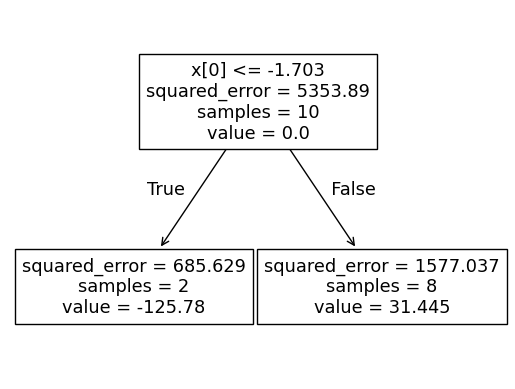

In [223]:
plot_tree(tree_1)

In [224]:
# Обновление предсказаний с учетом шага обучения
nu = 0.1
df['y_pred_1'] = df['y_pred_0'] + nu * df['tree_pred_1']
df

,0,1,2,y_true,y_pred_0,residual_0,tree_pred_1,y_pred_1
0,-2.596879,-1.271633,-0.204301,-207.864873,-55.900631,-151.964242,-125.779714,-68.478602
1,-1.750752,0.801927,-1.473314,-155.495817,-55.900631,-99.595187,-125.779714,-68.478602
2,0.394073,-0.873305,0.289681,26.305876,-55.900631,82.206506,31.444929,-52.756138
3,0.259596,-0.015685,0.935106,42.250301,-55.900631,98.150932,31.444929,-52.756138
4,0.025244,-1.008601,-0.495052,-21.757456,-55.900631,34.143175,31.444929,-52.756138
5,-0.499546,1.670300,-1.541367,-56.720023,-55.900631,-0.819392,31.444929,-52.756138
6,0.332632,-0.627695,-1.393813,-17.866647,-55.900631,38.033984,31.444929,-52.756138
7,-0.395146,0.260322,0.026375,-25.178411,-55.900631,30.722220,31.444929,-52.756138
8,-0.606944,-1.546873,-0.121507,-64.217109,-55.900631,-8.316478,31.444929,-52.756138
9,-1.654263,2.248090,0.673129,-78.462150,-55.900631,-22.561519,31.444929,-52.756138


In [225]:
# Вывод средней абсолютной ошибки на прошлой итерации
mean_absolute_error(df['y_true'], df['y_pred_0'])

56.651363561064976

In [226]:
mean_absolute_error(df['y_true'], df['y_pred_1'])

53.50687070715045

In [227]:
df = df[[0,1,2,'y_true']].copy()
n = 10
nu = 0.1
df['pred0'] = df['y_true'].mean()
df['residual0'] = df['y_true'] - df['pred0']
trees = []

for i in range(n):
    trees.append(DecisionTreeRegressor(max_depth=1, random_state=3))
    trees[i].fit(df[[0,1,2]], df['residual'+str(i)])
    df['tree_pred'+str(i)] = trees[i].predict(df[[0,1,2]])
    df['residual'+str(i+1)] = df['y_true'] - (df["pred0"]+sum([0.1*df["tree_pred"+str(j)] for j in range(i)]))

df

,0,1,2,y_true,pred0,residual0,tree_pred0,residual1,tree_pred1,residual2,...,tree_pred5,residual6,tree_pred6,residual7,tree_pred7,residual8,tree_pred8,residual9,tree_pred9,residual10
0,-2.596879,-1.271633,-0.204301,-207.864873,-55.900631,-151.964242,-125.779714,-151.964242,-125.779714,-139.386270,...,-65.059676,-105.698653,-79.514126,-99.192686,-73.008158,-91.241273,-32.966738,-83.940457,-31.141534,-80.643784
1,-1.750752,0.801927,-1.473314,-155.495817,-55.900631,-99.595187,-125.779714,-99.595187,-125.779714,-87.017215,...,-65.059676,-53.329598,-79.514126,-46.823631,-73.008158,-38.872218,-32.966738,-31.571402,-31.141534,-28.274728
2,0.394073,-0.873305,0.289681,26.305876,-55.900631,82.206506,31.444929,82.206506,31.444929,79.062014,...,27.882718,63.298006,19.878531,60.509734,18.252040,58.521881,32.966738,56.696677,31.141534,53.400003
3,0.259596,-0.015685,0.935106,42.250301,-55.900631,98.150932,31.444929,98.150932,31.444929,95.006439,...,27.882718,79.242431,19.878531,76.454160,18.252040,74.466306,32.966738,72.641103,31.141534,69.344429
4,0.025244,-1.008601,-0.495052,-21.757456,-55.900631,34.143175,31.444929,34.143175,31.444929,30.998682,...,27.882718,15.234675,19.878531,12.446403,18.252040,10.458550,32.966738,8.633346,31.141534,5.336672
5,-0.499546,1.670300,-1.541367,-56.720023,-55.900631,-0.819392,31.444929,-0.819392,31.444929,-3.963885,...,27.882718,-0.148950,19.878531,-2.937222,18.252040,-4.925075,-32.966738,-6.750279,-31.141534,-3.453605
6,0.332632,-0.627695,-1.393813,-17.866647,-55.900631,38.033984,31.444929,38.033984,31.444929,34.889491,...,27.882718,19.125484,19.878531,16.337212,18.252040,14.349359,32.966738,12.524155,31.141534,9.227481
7,-0.395146,0.260322,0.026375,-25.178411,-55.900631,30.722220,31.444929,30.722220,31.444929,27.577727,...,27.882718,11.813719,19.878531,9.025447,18.252040,7.037594,32.966738,5.212390,31.141534,1.915717
8,-0.606944,-1.546873,-0.121507,-64.217109,-55.900631,-8.316478,31.444929,-8.316478,31.444929,-11.460971,...,27.882718,-7.646036,19.878531,-10.434308,18.252040,-12.422161,-32.966738,-14.247365,-31.141534,-10.950691
9,-1.654263,2.248090,0.673129,-78.462150,-55.900631,-22.561519,31.444929,-22.561519,31.444929,-25.706012,...,-65.059676,-21.891077,19.878531,-15.385110,18.252040,-17.372963,-32.966738,-19.198167,-31.141534,-15.901493


In [228]:
df["pred"] = df["pred0"]+sum([0.1*df["tree_pred"+str(j)] for j in range(n)])
mean_absolute_error(df["y_true"], df["pred"])

24.970394266232017

```
53.50687070715045
50.67682713862738
48.12978792695661
43.316809134260964
40.45922367824837
36.41330131042354
34.50913103386692
31.058217930480236
29.430737509163958
27.477458302480663
```

In [229]:
test = df[[0,1,2,'y_true']].copy()
test['y_pred'] = test['y_true'].mean()

for tree in trees:
  test['tree_pred'] = tree.predict(test[[0,1,2]])
  test['y_pred'] += nu * test['tree_pred']
test

,0,1,2,y_true,y_pred,tree_pred
0,-2.596879,-1.271633,-0.204301,-207.864873,-130.335242,-31.141534
1,-1.750752,0.801927,-1.473314,-155.495817,-130.335242,-31.141534
2,0.394073,-0.873305,0.289681,26.305876,-23.979974,31.141534
3,0.259596,-0.015685,0.935106,42.250301,-23.979974,31.141534
4,0.025244,-1.008601,-0.495052,-21.757456,-23.979974,31.141534
5,-0.499546,1.670300,-1.541367,-56.720023,-56.380571,-31.141534
6,0.332632,-0.627695,-1.393813,-17.866647,-23.979974,31.141534
7,-0.395146,0.260322,0.026375,-25.178411,-23.979974,31.141534
8,-0.606944,-1.546873,-0.121507,-64.217109,-56.380571,-31.141534
9,-1.654263,2.248090,0.673129,-78.462150,-65.674811,-31.141534


In [230]:
from sympy import *
y_true, y_pred = symbols('y_true y_pred', real=True)
1/2*(y_true - y_pred)**2

0.5*(-y_pred + y_true)**2

In [231]:
diff(1/2*(y_true - y_pred)**2, y_pred)

1.0*y_pred - 1.0*y_true

In [232]:
-(y_true - y_pred) # наш градиент в коде

y_pred - y_true

---
##Подробный разбор кода по шагам:

### Импорт библиотек
```python
import pandas as pd
import numpy as np
from sklearn.datasets import make_regression, make_classification
from sklearn.metrics import mean_absolute_error, mean_squared_error, roc_auc_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree
```
- **make_regression** — функция для создания синтетических данных для задачи регрессии.
- **DecisionTreeRegressor** — модель решающего дерева для регрессии.
- **mean_absolute_error** — метрика для оценки качества модели (средняя абсолютная ошибка).

### Создание данных
```python
X, y = make_regression(n_samples=10, n_features=3, random_state=45)
df = pd.DataFrame(X)
df['y_true'] = y
```
- **X** — матрица признаков (10 строк, 3 столбца).
- **y** — целевая переменная (регрессионная задача).
- **df** — DataFrame, который содержит признаки и целевую переменную.

### Подготовка данных
```python
df = df[[0,1,2,'y_true']].copy()
n = 10
nu = 0.1
df['y_pred'] = df['y_true'].mean()
trees = []
```
- **df[[0,1,2,'y_true']].copy()** — копирование DataFrame с признаками и целевой переменной.
- **n = 10** — количество итераций (деревьев) в градиентном бустинге.
- **nu = 0.1** — скорость обучения (шаг градиентного спуска).
- **df['y_pred'] = df['y_true'].mean()** — начальное предсказание (среднее значение целевой переменной).
- **trees = []** — список для хранения обученных деревьев.

### Обучение модели (градиентный бустинг)
- вычисление остатков (разница между истинными значениями и предсказаниями).
- создание решающего дерева с максимальной глубиной 1 (пень).
- обучение дерева на остатках.
- предсказание дерева.
- обновление предсказаний с учетом шага обучения.
- добавление обученного дерева в список.
- вывод средней абсолютной ошибки на каждой итерации.

### Предсказание на тестовых данных
```python
test = df[[0,1,2,'y_true']].copy()
test['y_pred'] = test['y_true'].mean()
for tree in trees:
  test['tree_pred'] = tree.predict(test[[0,1,2]])
  test['y_pred'] += nu * test['tree_pred']
test
```
- **test = df[[0,1,2,'y_true']].copy()** — создание тестового набора данных.
- **test['y_pred'] = test['y_true'].mean()** — начальное предсказание (среднее значение целевой переменной).
- **for tree in trees:** — итерация по всем обученным деревьям.
- **test['tree_pred'] = tree.predict(test[[0,1,2]])** — предсказание текущего дерева.
- **test['y_pred'] += nu * test['tree_pred']** — обновление предсказаний с учетом шага обучения.
- **test** — вывод финальных предсказаний.

### Итог
Этот код реализует градиентный бустинг с использованием решающих деревьев. Основные шаги включают:
1. Создание синтетических данных.
2. Инициализация начальных предсказаний.
3. Обучение деревьев на остатках.
4. Обновление предсказаний с учетом шага обучения.
5. Оценка качества модели на каждой итерации.
6. Предсказание на тестовых данных.